# Scientific Computing Report - EMAT 30008

Josh Beal - 2005289 - gx20774@bristol.ac.uk

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from odes import solve_ode, RK4_step
from shooting import brusselator, brusspc, numshoot, plotorbit, hopf, hopfpc
from plot import plotsystemode, plotphaseportrait
from NumericalContinuation import natpar, plot_continuation
from BVP import solve_poisson, plot_poisson
from PDEs import xgrid, maxdt, explicit_euler, implicit_euler, diffusionIC, plot_pde



## Software Demonstration

## Question 1

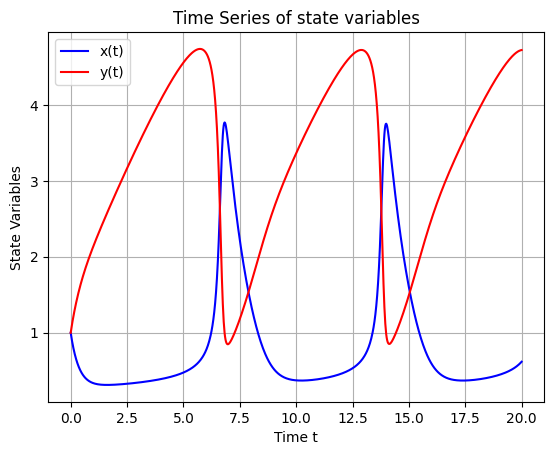

In [2]:
# 1a

# Parameters
f = brusselator
X0 = [1, 1]
t = np.linspace(0, 20, 1000)
method = 'RK4'
A = 1
B = 3

X = solve_ode(f, X0, t, method, A=A, B=B)

plotsystemode(X, t)


Shows going towards limit cycle as repeated behaviour. 

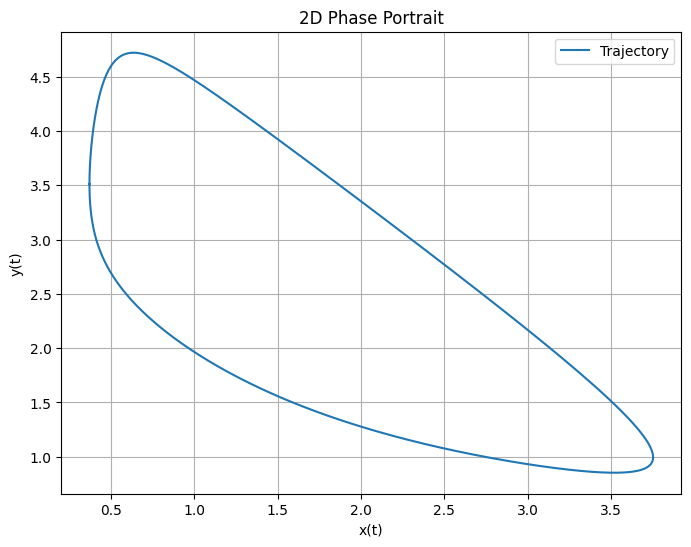

Optimized Initial Conditions: x(0) = 0.3706, y(0) = 3.5119
Optimized Period: T = 7.16


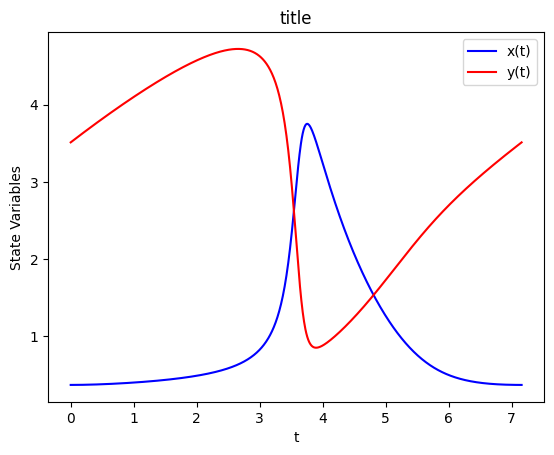

In [3]:
# 1b

f = brusselator
phasecondition = brusspc
X0 = [1, 1]
Tguess = 8
A = 1
B = 3

X0, T = numshoot(f, phasecondition, X0, Tguess, A=A, B=B)

x0, y0 = X0  
period = T
t = np.linspace(0, period, 1000)
X = solve_ode(f, X0, t, method, A=A, B=B)
plotphaseportrait(X)

print(f"Optimized Initial Conditions: x(0) = {x0:.4f}, y(0) = {y0:.4f}")
print(f"Optimized Period: T = {period:.2f}")
plotorbit(f, X0, T, A=A, B=B)

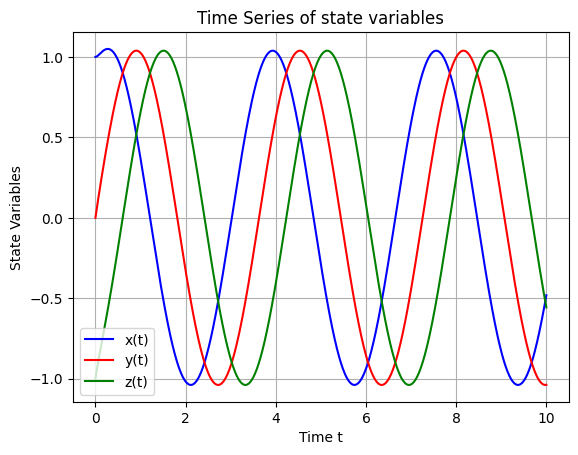

In [4]:
# 2a

f = hopf
X0 = [1, 0, -1]
t = np.linspace(0, 10, 1000)
method = 'RK4'
mu = 1

X = solve_ode(f, X0, t, method, mu=mu)

plotsystemode(X, t)

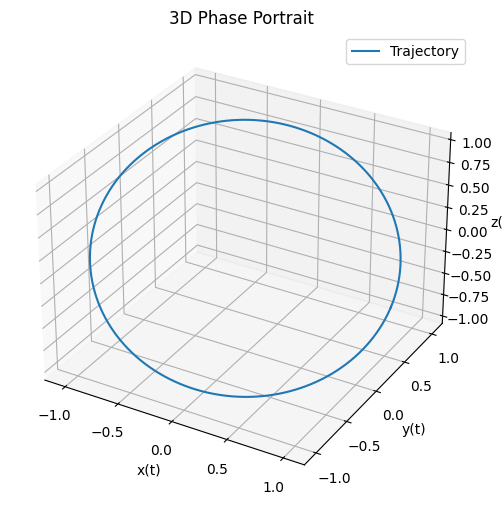

Optimized Initial Conditions: x(0) = 1.0332, y(0) = 0.5246 z(0) = -0.5246
Optimized Period: T = 3.63


In [5]:
# 2b

f = hopf
phasecondition = hopfpc
X0 = [1, 0, -1]
Tguess = 3
mu = 1

X0, T = numshoot(f, phasecondition, X0, Tguess, mu=mu)

x0, y0, z0 = X0  # Unpacking the optimized initial conditions
period = T
t = np.linspace(0, period, 1000)
X = solve_ode(f, X0, t, method, mu=mu)
plotphaseportrait(X)

print(f"Optimized Initial Conditions: x(0) = {x0:.4f}, y(0) = {y0:.4f}", f"z(0) = {z0:.4f}")
print(f"Optimized Period: T = {period:.2f}")
# T = 10
# plotorbit(f, X0, T, mu=mu)

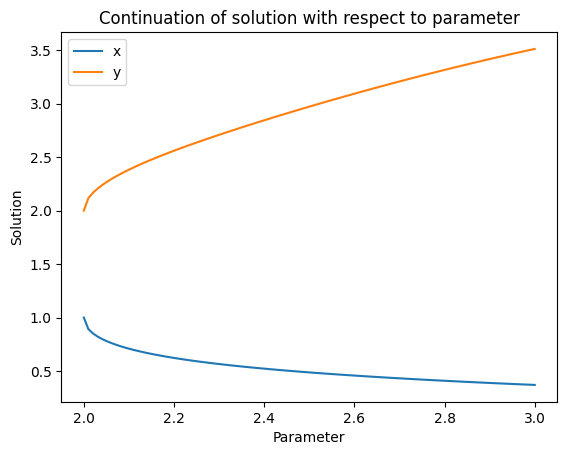

In [6]:
# 1c

f = brusselator
u0 = [0.4, 3.5]
parvalues = (3, 2, 100)
parameter = 'B'
Tguess = 6.5
phasecondition = brusspc
discretisation = 'shooting'
A = 1

u0, parvals, Ts = natpar(f, [u0], parvalues, parameter, Tguess, phasecondition, discretisation, A = A, B = B)
# print(parvals)
plot_continuation(u0, parvals)


Value of u at u(0) (for sigma=0.5) :-1.2432
Time to solve using dense method: 0.0015 seconds
Value of u at u(0) (for sigma=0.1) :-2.8377
Time to solve using sparse method: 0.0041 seconds


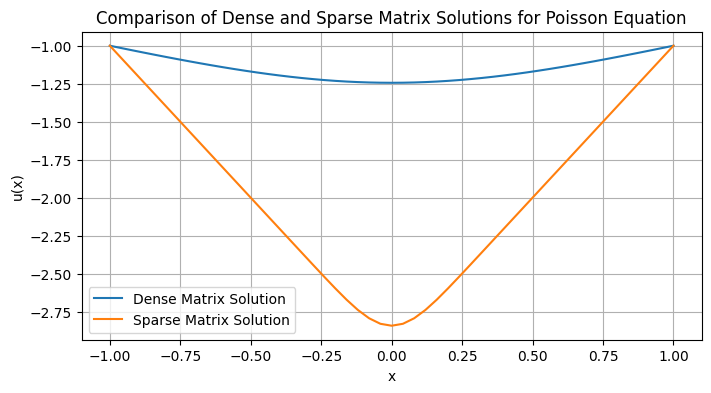

In [7]:
# 3a

lower_x = -1
upper_x = 1
num_points = 51
D = 1  # Diffusion
bc_left = -1  # Boundary condition at x = lower_x
bc_right = -1  # Boundary condition at x = upper_x

sigma = 0.5
xdense, udense, tdense = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'dense')
sigma = 0.1
xsparse, usparse, tsparse = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'sparse')

xlist = [xdense, xsparse]
ulist = [udense, usparse]
labels = ['Dense Matrix Solution', 'Sparse Matrix Solution']
title = 'Comparison of Dense and Sparse Matrix Solutions for Poisson Equation'
plot_poisson(xlist, ulist, labels, title)



Value of u at u(0) (for sigma=0.05) :-4.8304
Time to solve using dense method: 0.0910 seconds
Value of u at u(0) (for sigma=0.05) :-4.8304
Time to solve using sparse method: 0.0007 seconds


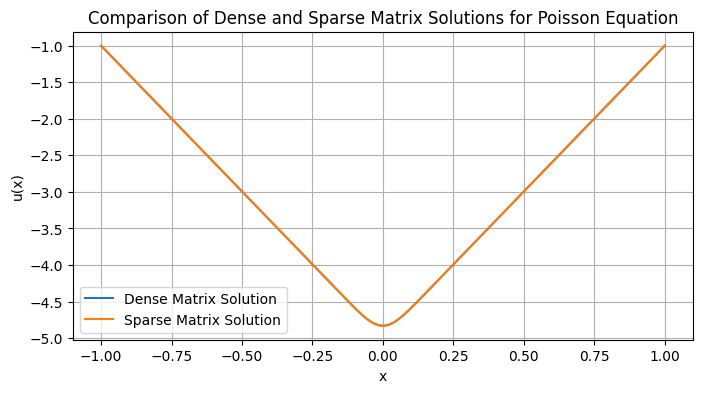

In [8]:
# 3b
lower_x = -1
upper_x = 1
num_points = 501
D = 1  # Diffusion
bc_left = -1  # Boundary condition at x = lower_x
bc_right = -1  # Boundary condition at x = upper_x

sigma = 0.05
xdense, udense, tdense = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'dense')
xsparse, usparse, tsparse = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'sparse')

xlist = [xdense, xsparse]
ulist = [udense, usparse]
labels = ['Dense Matrix Solution', 'Sparse Matrix Solution']
title = 'Comparison of Dense and Sparse Matrix Solutions for Poisson Equation'
plot_poisson(xlist, ulist, labels, title)

In [9]:
# 4a

L = 2
a = 0
b = L
N = 100
D = 0.5

x, dx, xint = xgrid(N, a, b)
dtmax = maxdt(D, dx)
print(f"Maximum time step for stability: {dtmax:.4f}")


Maximum time step for stability: 0.0004


Explicit method: u(0, T) = 0.0198
Implicit method: u(0, T) = 0.0198


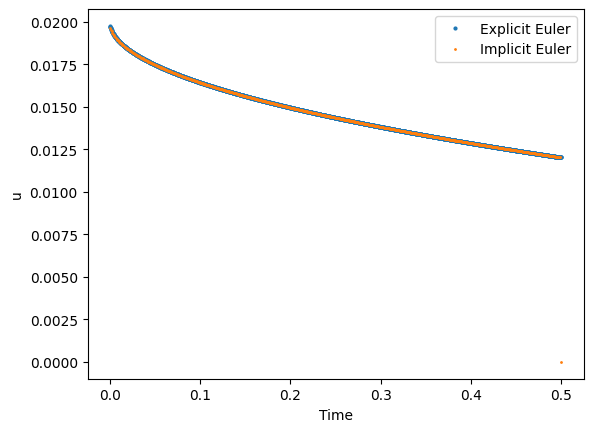

In [10]:
# 4b
L = 2
a = 0
b = L
N = 100
D = 0.5

def diffusionIC(xint, b):
    return 0.5 * xint * (b - xint)

IC = diffusionIC
alpha = 1
beta = 0
T = 0.5
dt = maxdt(D, dx)

expu, expt = explicit_euler(N, D, alpha, beta, a, b, dt*0.5, dx, T, xint, IC)

print(f"Explicit method: u(0, T) = {expu[0, -1]:.4f}")
expu1 = expu[1:,-1]

impu, impt = implicit_euler(N, D, alpha, beta, a, b, dt*2, dx, T, xint, IC)

print(f"Implicit method: u(0, T) = {impu[0, -1]:.4f}")
impu1 = impu[1:,-1]

plot_pde(expu1, impu1, expt, impt)




## Description of the key software design decisions

### ODEs

The `odes.py` module is structured to solve ordinary differential equations using multiple numerical methods. These include methods such as Euler, Runge-Kutta and Heun. The main function, `solve_ode`, uses a dictionary to map the names of each method so they can be implemented. This allows for flexibility in selection through the simple interface. This also allows for very easy extensions of the code. Any step could be added into the function without changing the functionality of the code. 
A decision I made for the `solve_ode` function was adaptive step size. This means that as long as t1 (time to solve to) is larger than the current value of t it will perform the next iterative step. It then checks if the current t plus the time step is still smaller than t1. If it is not it calculates the difference and will iterate once more before returning the final value. 
I also considered using an object-oriented approach, to use each method within a class. Whilst this is very helpful for code organisation and simplifying the parameters, I chose the functional approach to simplify the usage. This also allows other contributors to make easy changes.
By checking the inputs to the `solve_ode` we can ensure the inputs passed by the user is the correct type to be handled. If it is not correct, it will raise an error such as unrecognised method. It then guides users to the correct type improving overall user experience. 

### Shooting

The `shooting.py` module is made for solving boundary value problems using the shooting method. This method transforms a boundary value problem into an initial value problem, which is then solved using the ODE solvers from `odes.py`. It also uses the `findroot` function I created, passing parameters through the `numshoot`, `findroot`, `solve_ode` functions all the way to the numerical methods. The use of the different modules demonstrates the cohesive design of the software. The `shooting.py` module has a lot of flexibility with parameters as they are passed through to the `odes.py` functions. 
I chose to make the `Runge-Kutta` method the default solver within the shooting mechanism.  I decided it had the best accuracy whilst not using excessive computational power. Whilst other methods could provide better stability for different types of problems, the `RK4` method has a wide range of applications.
I visualised the time series with a `plotsystemode` function. I also had another function to plot the phase portrait. A further enhancement of this would be to integrate the plot into the shooting function iterating over any number of variables and systems of ODEs. 
The module also incorporates error handling non-convergence making sure the results are reliable.

### Continuation

The `NumericalContinuation.py` module is designed to explore solutions in parameterised systems, helping understand the bifurcations and stability in the mathematical models. This module implements natural parameter **continuation** and can navigate through complex solution landscapes. The continuation progresses through parameter values in small customised increments, calculating the solutions at every step.  This allows for tracing continuous solution branches and identifying where solutions may birfurcate or disappear. 
One key part of this function is the `try: except` block so that errors are caught and located but the code will still run without crashing. Another important part of numerical continuation is the visualisation as this often gives us much more of an insight into what is really happening when changing the parameters. This is another instance where having an automatic plotting function can improve general user experience. 
I have also attempted to implement pseudo arclength continuation into my module. Whilst I didn’t get to fully develop the code, I tried to extend the parameter space by considering changes in both the solution and the parameter which can allow it to find a way through bifurcations or folds.

### BVP

The `BVP.py` module uses the finite difference method to convert the boundary value problem into a system of equations that can be solved using numerical solvers. The continuous domain is discretised into a finite set of points whilst the differential equaitons are approximated using differences between these points. NumPy’s `linalg`solver was used for a variety of reasons. Mainly because NumPy is optimised for numerical computations and have a significant speed advantage, especially for large matrices which are common for discretisation of differential equations for BVPs. Whilst being high performance, it is also very simple to use. This reduces the potential for bugs as it keeps the code simple. 
The matrices are formed from the user inputs which can be specified to sparse or dense and each row approximates the differential equation at a specific point in the domain. Once the matrix and rhs vector are defined, the `linalg.solve` can be used to solve the dense linear system whilst `scipy.sparse.linalg`. We can then plot the results given to analyse and compare the dense and sparse matrix solutions.

### PDE

The `PDEs.py` module uses numerical methods to solve the 1-D diffusion equation, specifically through the explicit and implicit Euler methods. It divides the domain between a and b by generating a spatial grid using the `xgrid` function. It is split into N equally spaced segments. We can use this to calculate the grid spacing (dx) and therefore the maximum stable step size (dt) using the Diffusion Coefficient (D). Both methods implemented solve the diffusion equation by discretising the spatial derivatives. As they are similar functions try to calculate similar outputs, I kept my code very similar so that in the future, a function can be created to generalise the PDE solvers. As I only implemented two methods to start with, I focused on them individually rather than making a module to do both at this stage. The explicit Euler method updates directly from previous time steps, while the implicit method method involves solving a system of linear equations using `linalg.solve` for stability at large time steps. The initial conditions are set through the `diffusionIC` function. Again, the best way to analyse the findings is by plotting and for the PDEs we use the `plot_pde` function. 



## RLL

Introduction:
Briefly introduce the purpose of the log and what you hope to convey through your reflections.

Mathematical Algorithms:
Discuss specific algorithms you explored, such as ODEs and PDEs, and your learning process. Highlight any new techniques or significant insights gained and how they might apply to real-world problems.

Software Engineering:
Reflect on your development in software engineering practices, such as using version control systems like Git, understanding software testing, or improving code modularity and reusability. Mention any challenges faced and how you overcame them.

Reflective Practice:
Analyse what could have been done differently during the course. Consider aspects like preparation, engagement with the material, or integration of theory with practical applications.

Future Directions:
Outline how the skills and knowledge acquired will affect your future work or studies. Specify any changes you plan to implement in your approach to software engineering projects or continuing education.

Conclusion:
Summarize your key learning points and reflect on the overall impact of the unit on your professional growth and understanding.